In [1]:
from skimage.metrics import structural_similarity as ssim
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import BinaryPrecision, BinaryRecall, F1Score
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import numpy as np
from PIL import Image
import random
import json
import copy

import time
from torchmetrics.classification import MulticlassConfusionMatrix, F1Score, MulticlassPrecision, MulticlassRecall
from PhyDNet_models import ConvLSTM, PhyCell, ClassifierRNN
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, f1_score
from PhyDNet.constrain_moments import K2M
import torch.multiprocessing as mp
import pytorch_lightning as pl

import argparse
from tqdm import tqdm
import os
import re
import pandas as pd
from torchvision.io import read_image
from datetime import datetime
from pathlib import Path
import confinement_mode_classifier as cmc
from torch.utils.tensorboard import SummaryWriter


import PhyDNet_COMPASS as pdnt

In [2]:
path = Path(os.getcwd())
path_to_model='PhyDNet/runs/24-05-15, 12-53-51 PhyDNet_finetuning_last_conv/model_chkpt_best_acc.pt'
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

phycell  =  PhyCell(input_shape=(88,88), input_dim=352, F_hidden_dims=[49], n_layers=1, kernel_size=(7,7), device=device) 
convcell =  ConvLSTM(input_shape=(88,88), input_dim=352, hidden_dims=[8,352], n_layers=2, kernel_size=(3,3), device=device)   
classifier = ClassifierRNN(phycell, convcell, device)
classifier.load_state_dict(torch.load(f'{path}/{path_to_model}', map_location=torch.device('cpu')))
classifier = classifier.to(device)

layer  0 input dim  352  hidden dim  8
layer  1 input dim  8  hidden dim  352


In [3]:
classifier.named_parameters
layer_sizes_dict = {name: param.size() for name, param in classifier.named_parameters()}

In [4]:
layer_sizes = pd.read_csv('PhyDNet_weights_extraction_layer_sizes.csv')

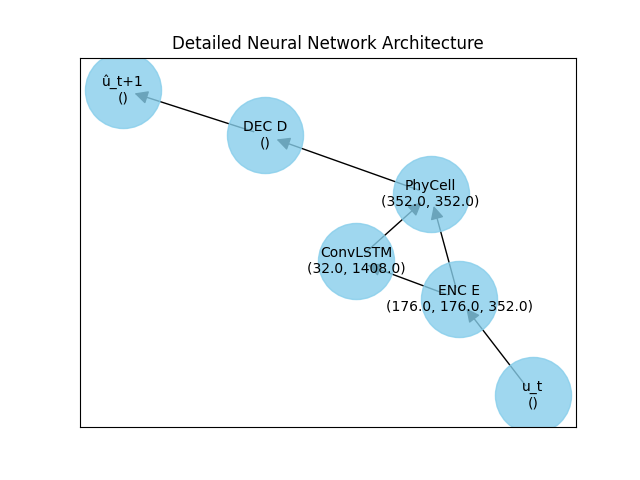

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib widget

# Define the graph
G = nx.DiGraph()

# Define nodes with detailed information
nodes = [
    ("Input", {"label": "u_t"}),
    ("Encoder", {"label": "ENC E", "layers": ["c1", "c2", "c3"], "sizes": layer_sizes.loc[0, ["encoder_E.c1.main.0.weight", "encoder_E.c2.main.0.weight", "encoder_E.c3.main.0.weight"]].tolist()}),
    ("PhyCell", {"label": "PhyCell", "layers": ["cell_list.0.F", "cell_list.0.convgate"], "sizes": layer_sizes.loc[0, ["phycell.cell_list.0.F.conv2.weight", "phycell.cell_list.0.convgate.weight"]].tolist()}),
    ("ConvLSTM", {"label": "ConvLSTM", "layers": ["cell_list.0", "cell_list.1"], "sizes": layer_sizes.loc[0, ["convcell.cell_list.0.conv.weight", "convcell.cell_list.1.conv.weight"]].tolist()}),
    ("Decoder", {"label": "DEC D"}),
    ("Output", {"label": "û_t+1"})
]

# Add nodes to the graph
for node, attr in nodes:
    G.add_node(node, **attr)

# Define edges
edges = [
    ("Input", "Encoder"),
    ("Encoder", "PhyCell"),
    ("Encoder", "ConvLSTM"),
    ("ConvLSTM", "PhyCell"),
    ("PhyCell", "Decoder"),
    ("Decoder", "Output")
]

# Add edges to the graph
G.add_edges_from(edges)

# Create a layout for the nodes
pos = nx.spring_layout(G, seed=42)

# Draw the nodes
node_labels = {node: f"{data['label']}\n({', '.join(map(str, data.get('sizes', [])))})" for node, data in G.nodes(data=True)}
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=3000, alpha=0.8)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10)

# Draw the edges
nx.draw_networkx_edges(G, pos, edgelist=edges, arrowstyle='-|>', arrowsize=20)

# Title and show plot
plt.title("Detailed Neural Network Architecture")
plt.show()


In [1]:
import xarray as xr

data = xr.open_dataset('/compass/Shared/Users/bogdanov/ml_tokamak/PhyDNet/runs/24-07-28, 00-33-37 phydnet, smaller time-diff, 5 images, onecycleLR/model_chkpt_filter_data.nc')


In [2]:
a = xr.concat([data, data], dim='new')


In [3]:
a = xr.concat([a, data], dim='new')
a

<xarray.Dataset>
Dimensions:      (new: 3, iter: 705, in_channels: 49, rows: 7, cols: 7, value: 1)
Dimensions without coordinates: new, iter, in_channels, rows, cols, value
Data variables:
    filters      (new, iter, in_channels, rows, cols) float32 -0.002075 ... -...
    m            (new, iter, in_channels, rows, cols) float32 -0.0003977 ... ...
    constraints  (new, iter, in_channels, rows, cols) float32 1.0 0.0 ... 1.0
    b            (new, iter, value) int32 351 0 1 2 3 4 ... 347 348 349 350 351
    step         (new, iter, value) int32 8 12 12 12 12 12 ... 16 16 16 16 16 16

In [4]:
a.b

<xarray.DataArray 'b' (new: 3, iter: 705, value: 1)>
array([[[351],
        [  0],
        [  1],
        ...,
        [349],
        [350],
        [351]],

       [[351],
        [  0],
        [  1],
        ...,
        [349],
        [350],
        [351]],

       [[351],
        [  0],
        [  1],
        ...,
        [349],
        [350],
        [351]]], dtype=int32)
Dimensions without coordinates: new, iter, value